In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt

from skimage import io, color, filters, morphology, segmentation, feature, exposure
from scipy import ndimage as ndi

plt.rcParams["figure.figsize"] = (8,8)


In [11]:
PASTA_IMAGENS = "/content/"

imagens = []
nomes_imagens = []

for nome in os.listdir(PASTA_IMAGENS):
    if nome.lower().endswith((".jpg", ".png", ".jpeg")):
        caminho = os.path.join(PASTA_IMAGENS, nome)
        img = io.imread(caminho)

        if len(img.shape) == 3:
            img = color.rgb2gray(img)

        imagens.append(img)
        nomes_imagens.append(nome)

print(f"{len(imagens)} imagens carregadas")

12 imagens carregadas


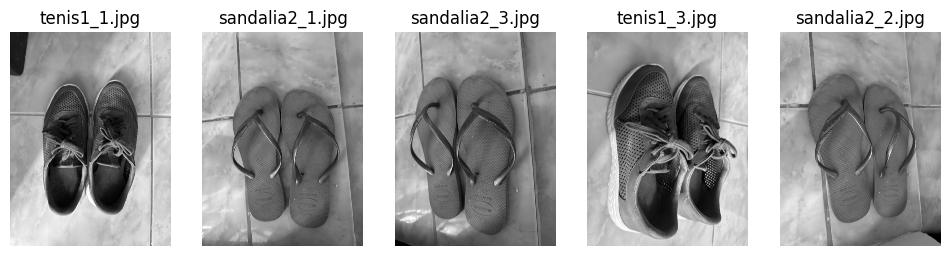

In [12]:
plt.figure(figsize=(12,5))

for i, img in enumerate(imagens[:5]):
    plt.subplot(1,5,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(nomes_imagens[i])
    plt.axis("off")

plt.show()


In [13]:
# Gaussian + Equalização
preprocessadas = []

for img in imagens:

    # Gaussian
    blur = filters.gaussian(img, sigma=1.5)

    # Equalização
    eq = exposure.equalize_adapthist(blur)

    preprocessadas.append(eq)

In [40]:
# Máscara binária sólida (Otsu + Opening/Closing)
mascaras = []

selem = morphology.disk(5)

for img in preprocessadas:
    # Threshold (Otsu) em imagem equalizada
    th = filters.threshold_otsu(img)
    binary = img < th  # objetos (calçados) tendem a ser mais escuros

    # Morfologia para limpar e preencher
    binary = morphology.opening(binary, selem)
    binary = morphology.closing(binary, selem)

    # Remover pequenos ruídos
    binary = morphology.remove_small_objects(binary, min_size=2000)

    # Preencher buracos internos (tiras / cadarços geram buracos)
    binary = ndi.binary_fill_holes(binary)

    mascaras.append(binary)


In [41]:
# Distance Transform + Marcadores
distancias = []
marcadores_lista = []

for mask in mascaras:
    dist = ndi.distance_transform_edt(mask)
    distancias.append(dist)

    # marcadores: picos locais na distância
    coords = feature.peak_local_max(dist, footprint=np.ones((60, 40)), labels=mask)
    marcadores = np.zeros(dist.shape, dtype=bool)
    marcadores[tuple(coords.T)] = True
    marcadores = ndi.label(marcadores)[0]

    marcadores_lista.append(marcadores)

In [42]:
# Watershed com marcadores
labels_lista = []

for i in range(len(mascaras)):
    labels = segmentation.watershed(
        -distancias[i],
        marcadores_lista[i],
        mask=mascaras[i]
    )
    labels_lista.append(labels)

In [43]:
# Filtrar regiões por área
objetos_detectados = []

for labels in labels_lista:
    props = measure.regionprops(labels)

    if len(props) == 0:
        objetos_detectados.append(np.zeros_like(labels, dtype=bool))
        continue

    # Ordena por área (desc)
    props = sorted(props, key=lambda r: r.area, reverse=True)
    manter = props[:2]

    mask_final = np.zeros_like(labels, dtype=bool)
    for r in manter:
        mask_final[labels == r.label] = True

    objetos_detectados.append(mask_final)

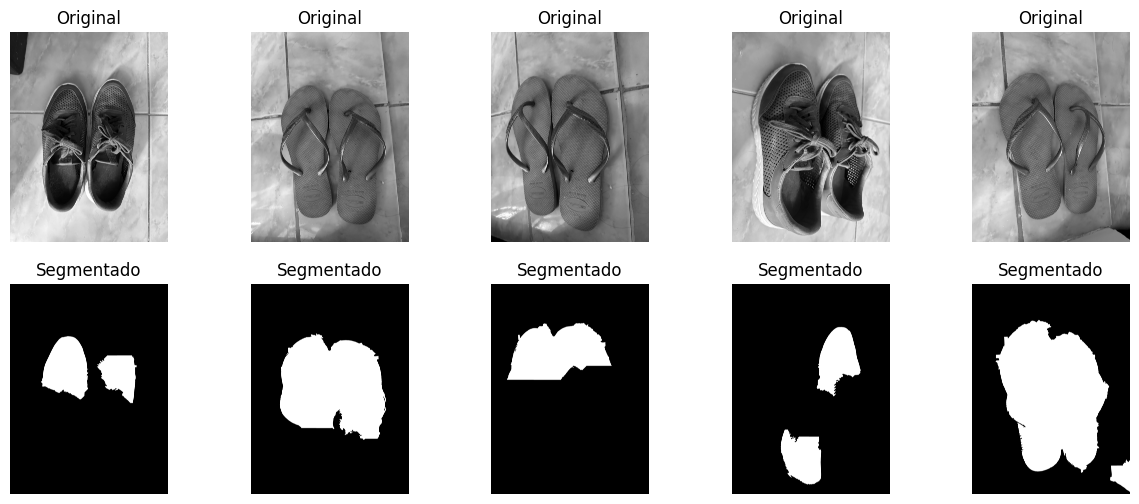

In [44]:
plt.figure(figsize=(15,6))

for i in range(min(5, len(imagens))):

    plt.subplot(2,5,i+1)
    plt.imshow(imagens[i], cmap='gray')
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2,5,i+6)
    plt.imshow(objetos_detectados[i], cmap='gray')
    plt.title("Segmentado")
    plt.axis("off")

plt.show()
